In [1]:
import decoupler as dc
import numpy as np
import pandas as pd
import pertpy as pt
import scanpy as sc

c:\Users\asd123cheese\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata_pb = sc.read_h5ad("../data_processed/pseudobulk.h5ad")

In [3]:
adata_pb.layers['counts'] = adata_pb.X.copy()

sc.pp.normalize_total(adata_pb, target_sum=1e5)
sc.pp.log1p(adata_pb)
sc.pp.scale(adata_pb, max_value=10)
sc.tl.pca(adata_pb)

dc.pp.swap_layer(adata=adata_pb, key="counts", inplace=True)

In [4]:
adata_pb.obs["psbulk_counts_log"] = np.log(adata_pb.obs["psbulk_counts"])
adata_pb.obs["psbulk_cells_log"] = np.log(adata_pb.obs["psbulk_cells"])

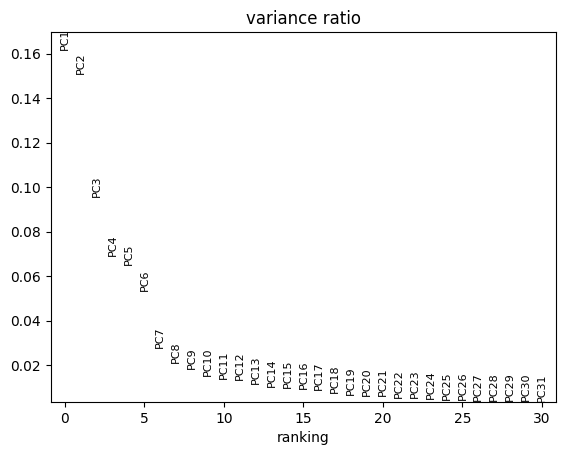

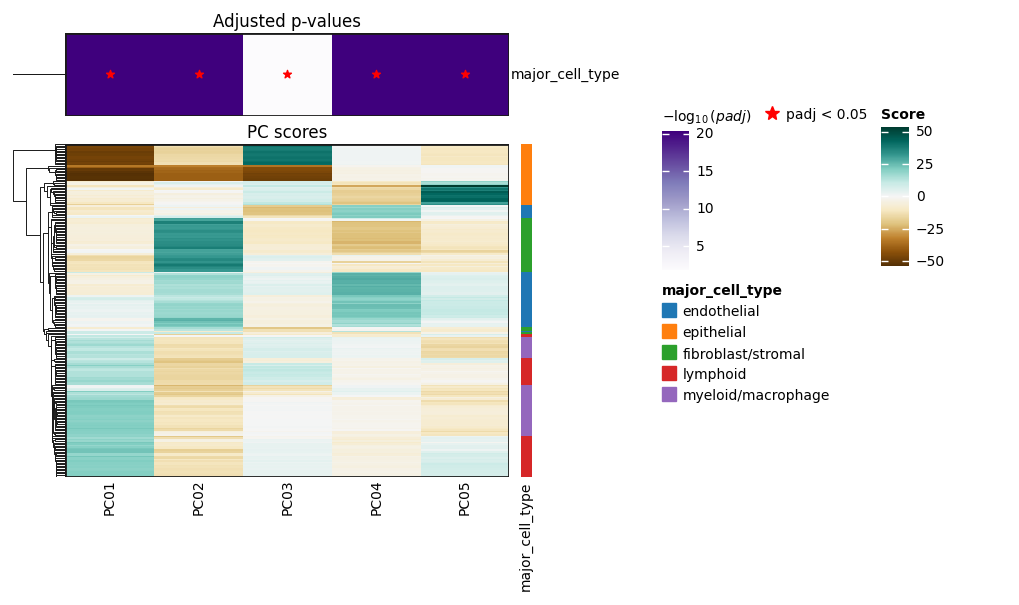

In [8]:
dc.tl.rankby_obsm(adata_pb, key="X_pca", obs_keys=['major_cell_type'])
sc.pl.pca_variance_ratio(adata_pb)
dc.pl.obsm(
    adata=adata_pb,
    return_fig=True,
    nvar=5,
    titles=["PC scores", "Adjusted p-values"],
    figsize=(10, 5)
)

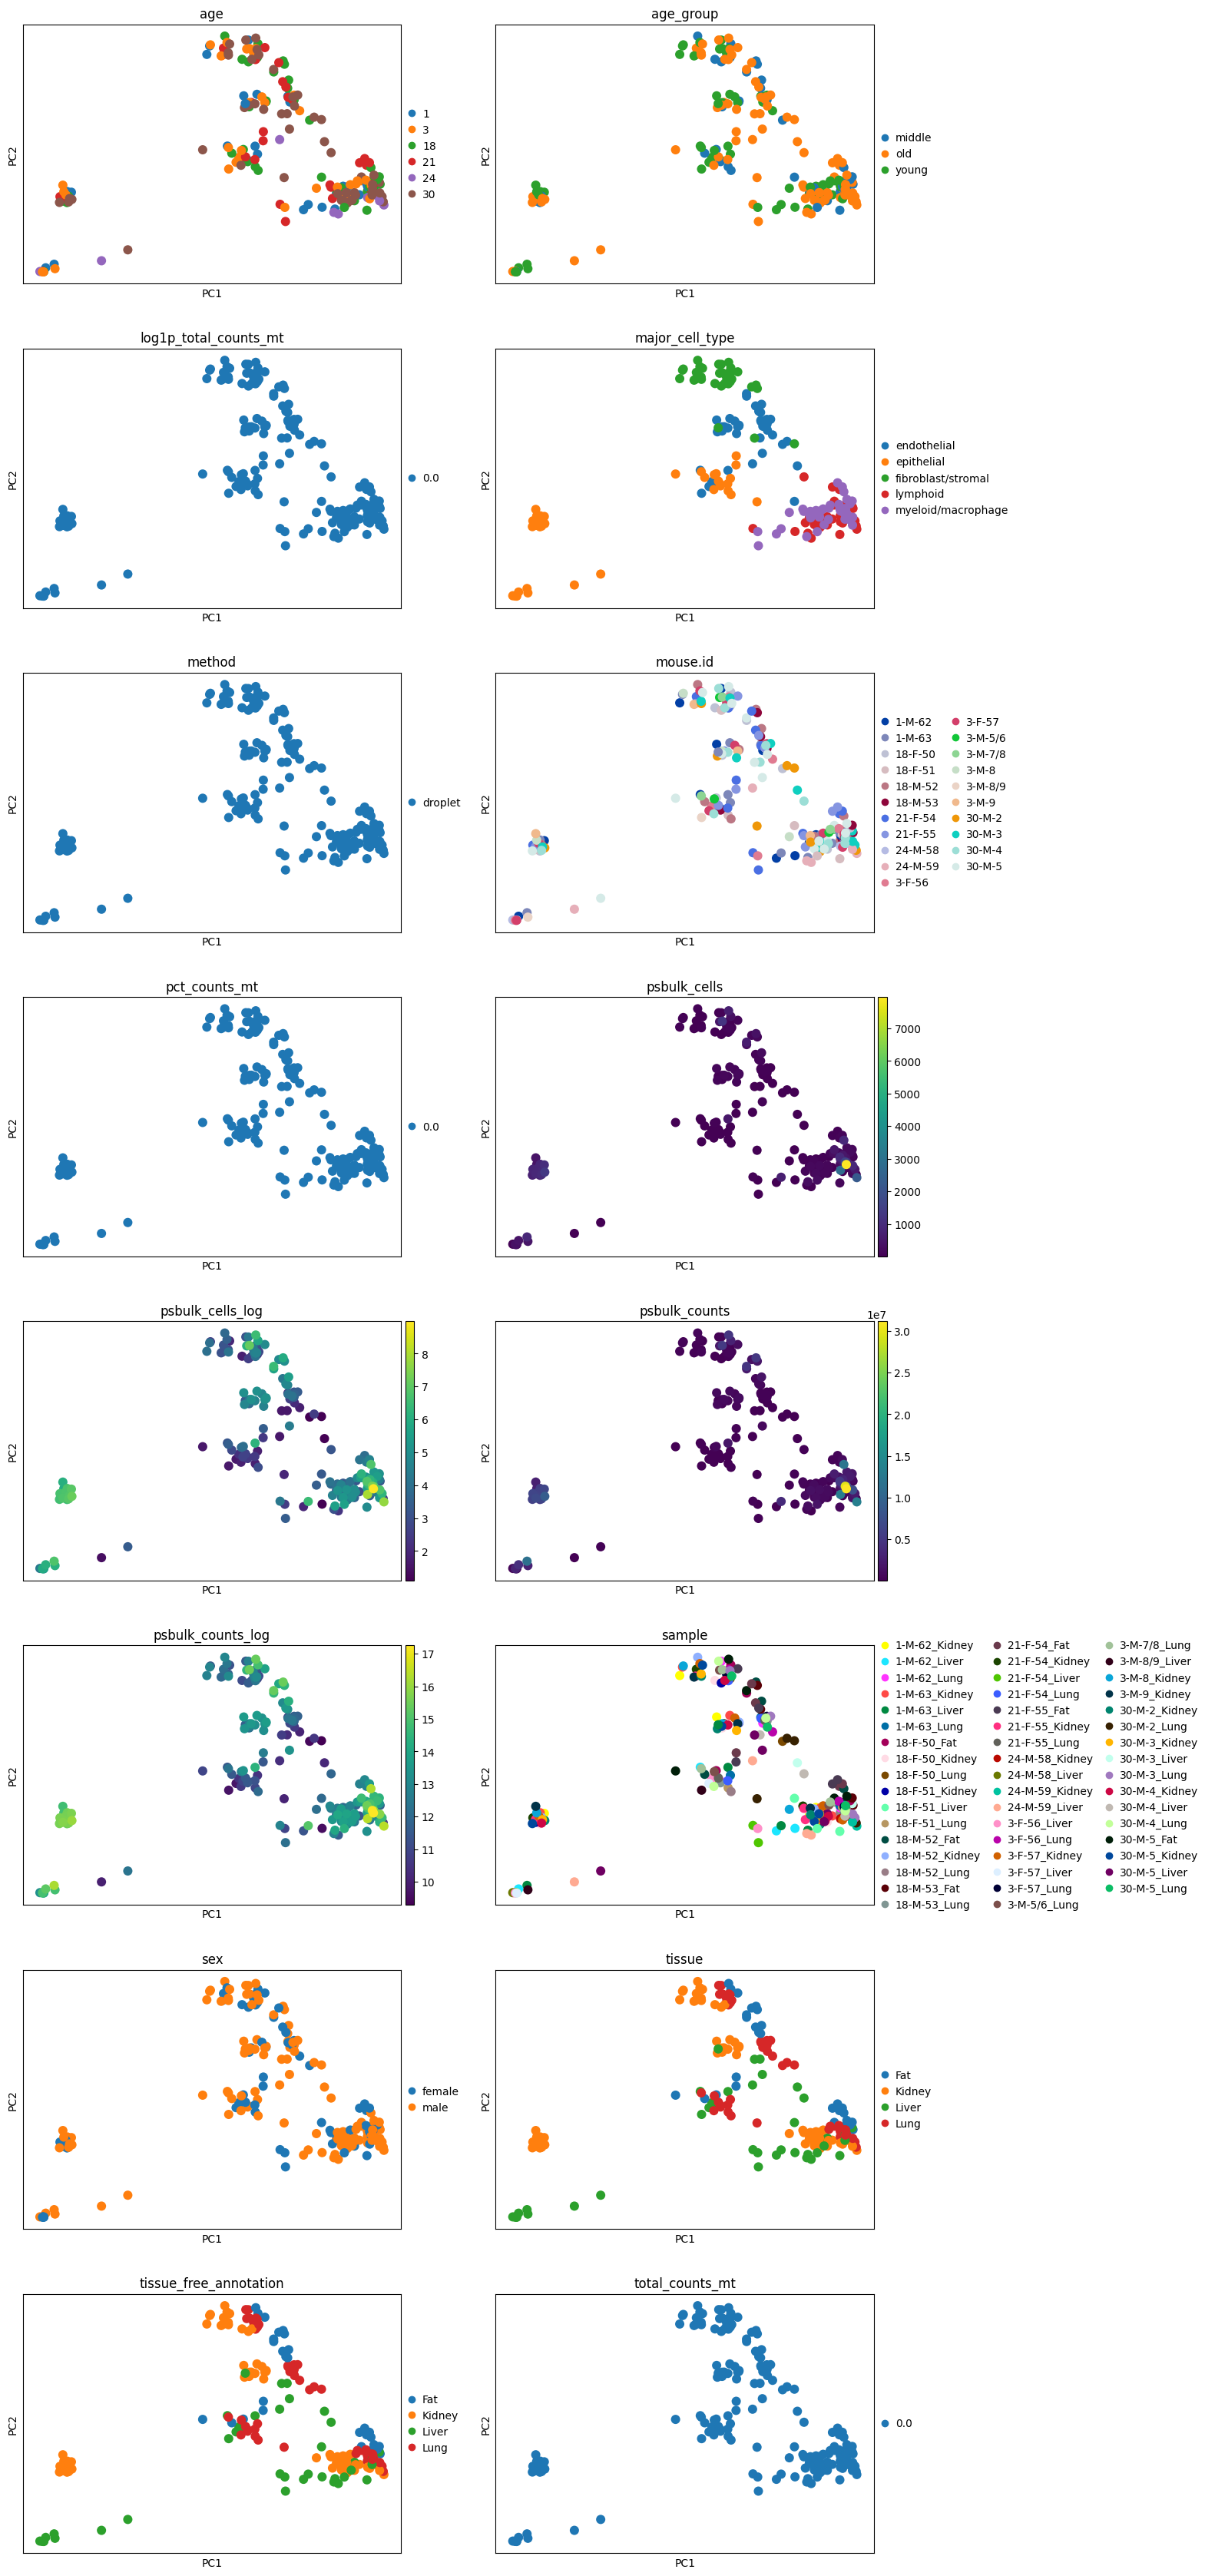

In [9]:
adata_pb.obs = adata_pb.obs.sort_index(axis=1)
sc.pl.pca(adata_pb, color=adata_pb.obs, ncols=2, size=300)

In [14]:
pds2 = pt.tl.PyDESeq2(adata=adata_pb, design="~ age + sex + tissue + major_cell_type")

In [15]:
pds2.fit()

Fitting size factors...
... done in 0.10 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 3.72 seconds.

Fitting dispersion trend curve...
... done in 0.36 seconds.

Fitting MAP dispersions...
... done in 4.20 seconds.

Fitting LFCs...
... done in 5.21 seconds.

Calculating cook's distance...
... done in 0.13 seconds.

Replacing 0 outlier genes.



In [16]:
res_df = pds2.compare_groups(
    adata_pb,
    column="major_cell_type",
    baseline="myeloid/macrophage",
    groups_to_compare=["lymphoid"]
)

Fitting size factors...
... done in 0.10 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 3.23 seconds.

Fitting dispersion trend curve...
... done in 0.38 seconds.

Fitting MAP dispersions...
... done in 3.46 seconds.

Fitting LFCs...
... done in 3.52 seconds.

Calculating cook's distance...
... done in 0.26 seconds.

Replacing 178 outlier genes.

Fitting dispersions...
... done in 0.13 seconds.

Fitting MAP dispersions...
... done in 0.11 seconds.

Fitting LFCs...
... done in 0.19 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [ 0.  0.  0.  1. -1.]
          baseMean  log2FoldChange     lfcSE      stat        pvalue  \
index                                                                  
Sox17    35.882381       -0.008101  0.469395 -0.017259  9.862298e-01   
Mrpl15   31.927515        0.272947  0.101416  2.691377  7.115777e-03   
Lypla1   34.273121        0.118612  0.132222  0.897068  3.696827e-01   
Tcea1    44.105199        0.242734  0.073036  3.323502  8.889474e-04   
Atp6v1h  17.599892       -0.612310  0.112090 -5.462652  4.690735e-08   
...            ...             ...       ...       ...           ...   
Kdm5d     2.570921        0.575878  0.477784  1.205312  2.280827e-01   
Eif2s3y  18.000947        0.317334  0.543125  0.584274  5.590357e-01   
Uty       1.996044       -0.248635  0.479986 -0.518005  6.044545e-01   
Ddx3y    23.244563        0.286466  0.553745  0.517325  6.049295e-01   
Erdr1    30.582056        0.189150  0.201797  0.937326  3.4

... done in 0.68 seconds.



NaNs encountered, dropping rows with NaNs


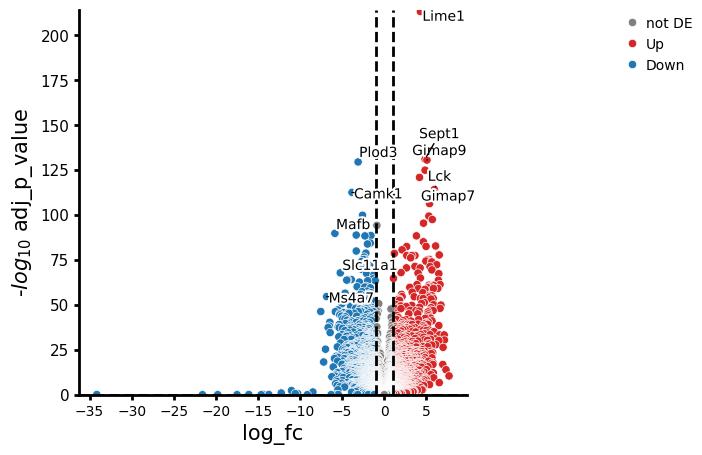

In [28]:
# 找出所有显著差异基因
pds2.plot_volcano(data=res_df, log2fc_threshold=1, padj_threshold=1)


=== lymphoid vs myeloid/macrophage ===
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.11 seconds.

Fitting dispersions...
... done in 2.87 seconds.

Fitting dispersion trend curve...
... done in 0.29 seconds.

Fitting MAP dispersions...
... done in 3.09 seconds.

Fitting LFCs...
... done in 3.10 seconds.

Calculating cook's distance...
... done in 0.22 seconds.

Replacing 178 outlier genes.

Fitting dispersions...
... done in 0.10 seconds.

Fitting MAP dispersions...
... done in 0.10 seconds.

Fitting LFCs...
... done in 0.16 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [ 0.  0.  0.  1. -1.]
          baseMean  log2FoldChange     lfcSE      stat        pvalue  \
index                                                                  
Sox17    35.882381       -0.008101  0.469395 -0.017259  9.862298e-01   
Mrpl15   31.927515        0.272947  0.101416  2.691377  7.115777e-03   
Lypla1   34.273121        0.118612  0.132222  0.897068  3.696827e-01   
Tcea1    44.105199        0.242734  0.073036  3.323502  8.889474e-04   
Atp6v1h  17.599892       -0.612310  0.112090 -5.462652  4.690735e-08   
...            ...             ...       ...       ...           ...   
Kdm5d     2.570921        0.575878  0.477784  1.205312  2.280827e-01   
Eif2s3y  18.000947        0.317334  0.543125  0.584274  5.590357e-01   
Uty       1.996044       -0.248635  0.479986 -0.518005  6.044545e-01   
Ddx3y    23.244563        0.286466  0.553745  0.517325  6.049295e-01   
Erdr1    30.582056        0.189150  0.201797  0.937326  3.4

... done in 0.66 seconds.

c:\Users\asd123cheese\AppData\Local\Programs\Python\Python314\Lib\site-packages\pertpy\tools\_differential_gene_expression\_base.py:830: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


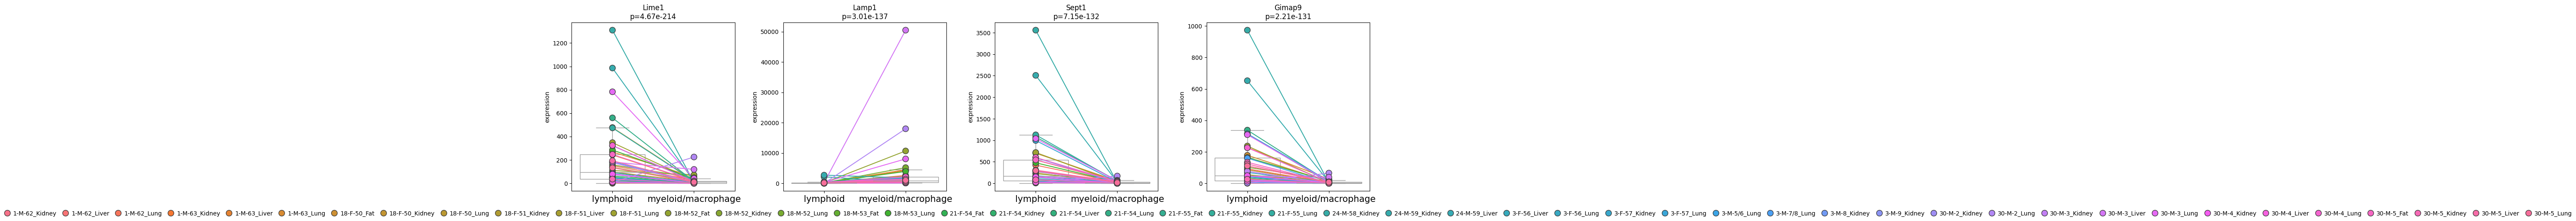


=== epithelial vs fibroblast/stromal ===
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.13 seconds.

Fitting dispersions...
... done in 3.09 seconds.

Fitting dispersion trend curve...
... done in 0.29 seconds.

Fitting MAP dispersions...
... done in 3.50 seconds.

Fitting LFCs...
... done in 3.45 seconds.

Calculating cook's distance...
... done in 0.21 seconds.

Replacing 178 outlier genes.

Fitting dispersions...
... done in 0.08 seconds.

Fitting MAP dispersions...
... done in 0.09 seconds.

Fitting LFCs...
... done in 0.18 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [ 0.  1. -1.  0.  0.]
          baseMean  log2FoldChange     lfcSE       stat        pvalue  \
index                                                                   
Sox17    35.882381       -4.306769  0.486123  -8.859429  8.042566e-19   
Mrpl15   31.927515        0.640639  0.122148   5.244771  1.564767e-07   
Lypla1   34.273121        2.245036  0.154822  14.500718  1.198890e-47   
Tcea1    44.105199       -0.296638  0.087551  -3.388172  7.036020e-04   
Atp6v1h  17.599892        1.130054  0.133634   8.456338  2.759052e-17   
...            ...             ...       ...        ...           ...   
Kdm5d     2.570921        0.254890  0.559243   0.455776  6.485509e-01   
Eif2s3y  18.000947       -0.117452  0.604931  -0.194159  8.460517e-01   
Uty       1.996044        0.460936  0.541199   0.851694  3.943841e-01   
Ddx3y    23.244563       -0.779527  0.610511  -1.276843  2.016578e-01   
Erdr1    30.582056        0.062681  0.228132   

... done in 0.75 seconds.

c:\Users\asd123cheese\AppData\Local\Programs\Python\Python314\Lib\site-packages\pertpy\tools\_differential_gene_expression\_base.py:830: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


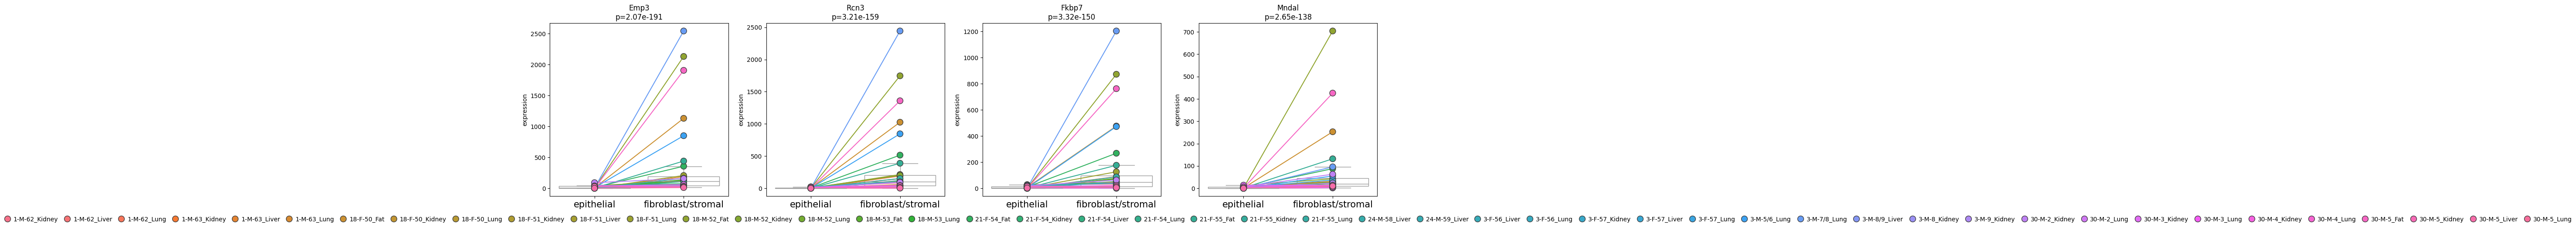


=== endothelial vs lymphoid ===
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.11 seconds.

Fitting dispersions...
... done in 3.05 seconds.

Fitting dispersion trend curve...
... done in 0.31 seconds.

Fitting MAP dispersions...
... done in 3.24 seconds.

Fitting LFCs...
... done in 2.93 seconds.

Calculating cook's distance...
... done in 0.20 seconds.

Replacing 178 outlier genes.

Fitting dispersions...
... done in 0.10 seconds.

Fitting MAP dispersions...
... done in 0.09 seconds.

Fitting LFCs...
... done in 0.16 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [ 0.  0.  0. -1.  0.]
          baseMean  log2FoldChange     lfcSE       stat        pvalue  \
index                                                                   
Sox17    35.882381        7.334656  0.441082  16.628787  4.312399e-62   
Mrpl15   31.927515       -0.019376  0.112891  -0.171633  8.637260e-01   
Lypla1   34.273121        0.424784  0.142997   2.970578  2.972401e-03   
Tcea1    44.105199        0.175050  0.081571   2.145979  3.187462e-02   
Atp6v1h  17.599892        0.880357  0.125589   7.009807  2.386475e-12   
...            ...             ...       ...        ...           ...   
Kdm5d     2.570921       -0.031789  0.514268  -0.061813  9.507116e-01   
Eif2s3y  18.000947       -0.614492  0.561180  -1.094999  2.735169e-01   
Uty       1.996044        0.795611  0.517639   1.536999  1.242934e-01   
Ddx3y    23.244563        0.150514  0.566821   0.265541  7.905925e-01   
Erdr1    30.582056       -0.105042  0.214911  -

... done in 0.63 seconds.

c:\Users\asd123cheese\AppData\Local\Programs\Python\Python314\Lib\site-packages\pertpy\tools\_differential_gene_expression\_base.py:830: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


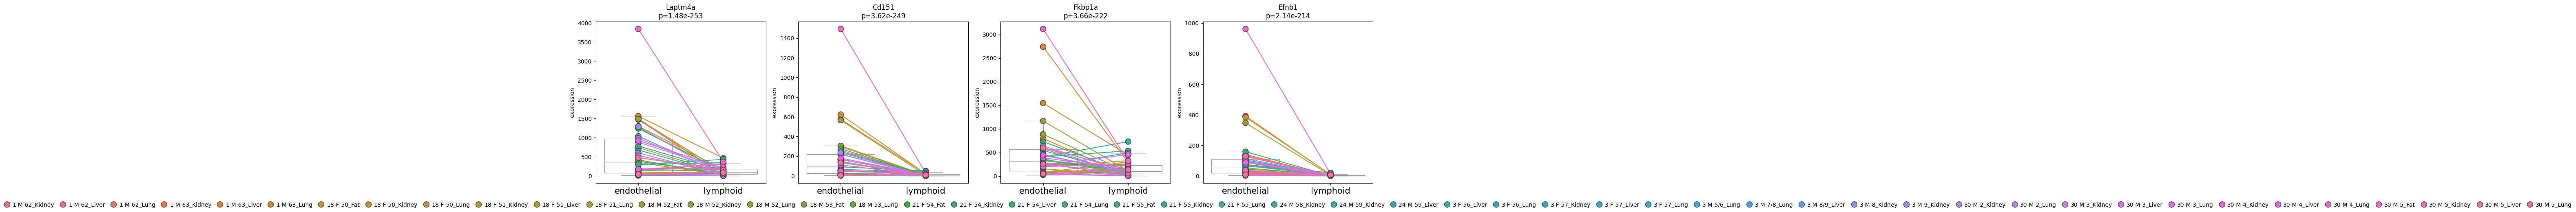